# 🎯 Predictive Insight Engine

### 🧠 Part A: Conceptual Understanding (Theory)

#### Q1. What are Supervised Learning Algorithms?

Supervised Learning Algorithms are ML algorithms trained on labeled data — where each input has a corresponding correct output. The model learns a mapping function from inputs to outputs. Examples include Linear Regression, Decision Trees, and SVM. The goal is to predict outputs for new, unseen data.

#### Q2. Difference between Regression vs Classification Algorithms

Aspect Regression Classification OutputContinuous valueDiscrete class/labelExamplePredicting house priceSpam vs Not SpamMetricMSE, RMSE, R²Accuracy, F1, AUCAlgorithmLinear RegressionLogistic Regression, SVM

#### Q3. Explain Simple Linear Regression

Simple Linear Regression models the relationship between one independent variable (X) and a dependent variable (Y) using a straight line:

**Y = β₀ + β₁X + ε**

- β₀ = intercept (value of Y when X=0)
- β₁ = slope (change in Y per unit change in X)
- ε = error term

The model minimizes the Sum of Squared Errors (SSE) to find the best-fit line.

#### Q4. Assumptions of Linear Regression

1. Linearity — Relationship between X and Y is linear
2. Independence — Observations are independent of each other
3. Homoscedasticity — Constant variance of residuals across all levels of X
4. Normality of Errors — Residuals are normally distributed
5. No Multicollinearity — Independent variables are not highly correlated (for MLR)
6. No Autocorrelation — Residuals are not correlated with each other


#### Q5. What is Bias–Variance Trade-Off?

- Bias = Error from wrong assumptions; high bias → underfitting
- Variance = Sensitivity to small fluctuations in training data; high variance → overfitting
- Trade-off: Reducing bias increases variance and vice versa
- Goal: Find the sweet spot where Total Error = Bias² + Variance + Irreducible Error is minimized


#### Q6. Explain Overfitting and Underfitting with Examples

- Underfitting: Model is too simple; fails to capture patterns

  - Example: Using a straight line to fit data that has a curve → high training & test error


- Overfitting: Model is too complex; memorizes training data including noise

  - Example: Degree-10 polynomial on 20 data points → very low training error but high test error


- Solution: Cross-validation, regularization (Ridge/Lasso), more data


### 🧪 Part B: Dataset Understanding & Preparation

**Dataset Features:**

- House Area (sq.ft) | Bedrooms | Bathrooms | Location Score | Age of Property | House Price (Target)


#### Q7. Identify Independent and Dependent Variables

- Independent Variables (Features/Predictors):

   - House Area, Number of Bedrooms, Number of Bathrooms, Location Score, Age of Property


- Dependent Variable (Target):

   - House Price

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [4]:
df = pd.read_csv("house_prices.csv")
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [9]:
df.columns = df.columns.str.strip()

X = df.drop("house_price_inr", axis=1)
y = df["house_price_inr"]

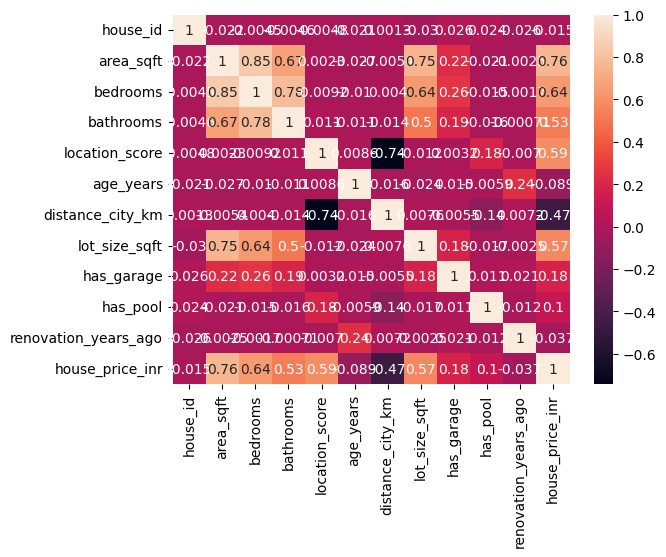

In [10]:
sns.heatmap(df.corr(), annot=True)
plt.show()

#### ✅ Task 9: Train-Test Split
📌 What to write:

We split the dataset into:

- Training set (80%) → to train model
- Testing set (20%) → to test model

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 📊 Part C: Simple Linear Regression

#### ✅ Task 10: Implement Simple Linear Regression

In [23]:
X_simple = df[["area_sqft"]]   
y = df["house_price_inr"]

model = LinearRegression()
model.fit(X_train, y_train)
# print(df.columns)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

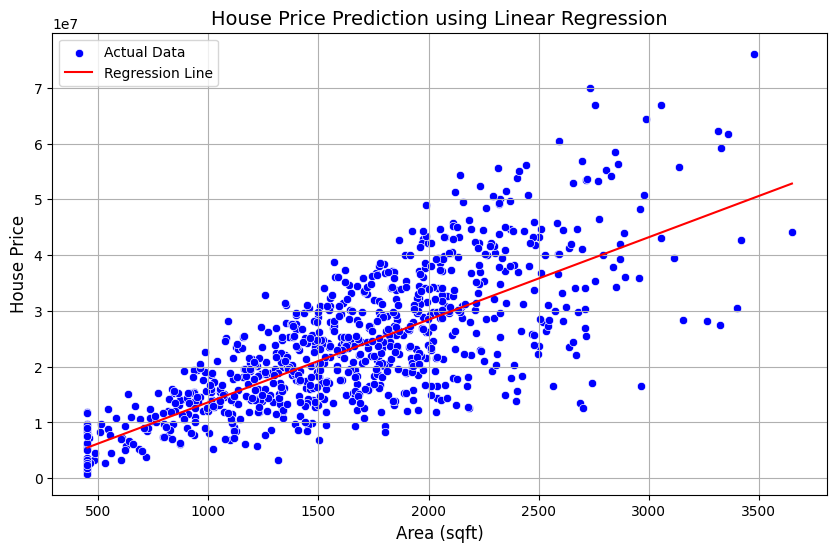

In [28]:

plt.figure(figsize=(10,6))

sns.scatterplot(x=X_test.values.flatten(), y=y_test, color='blue', label="Actual Data")

sns.lineplot(x=X_test.values.flatten(), y=y_pred, color='red', label="Regression Line")

plt.xlabel("Area (sqft)", fontsize=12)
plt.ylabel("House Price", fontsize=12)
plt.title("House Price Prediction using Linear Regression", fontsize=14)

plt.legend()
plt.grid(True)
plt.show()

In [26]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 14788.306111307536
Intercept: -1163519.1764186025


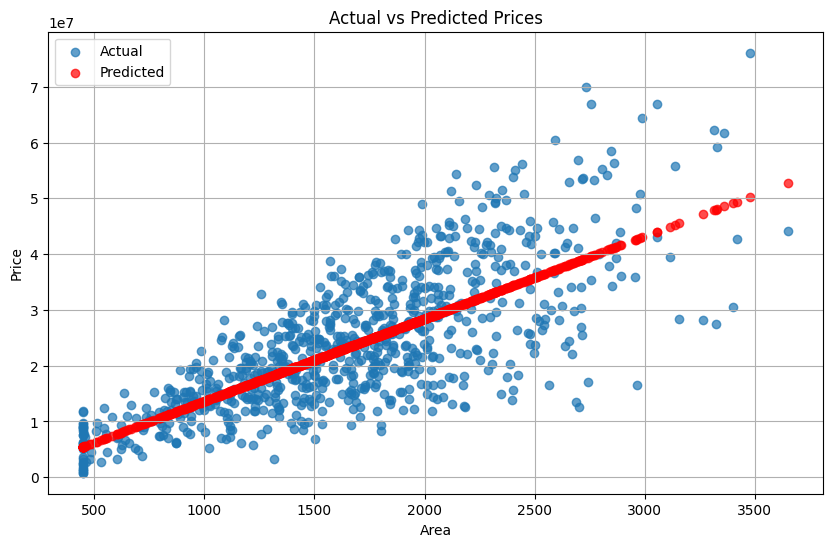

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, label="Actual", alpha=0.7)

plt.scatter(X_test, y_pred, color='red', label="Predicted", alpha=0.7)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()